<a href="https://colab.research.google.com/github/LucifersBossyCat/Wearable-Based-Cardiovascular-Strain-Prediction-with-Early-Warning-Detection/blob/main/CVD_EWS_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install any missing packages (scikit-learn, pandas, matplotlib are pre-installed on Colab)
# Uncomment if needed:
# !pip install scikit-learn pandas numpy matplotlib joblib -q

In [2]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

import joblib

print('All imports successful.')

All imports successful.


In [3]:
# Create output folders
OUTPUT_DIR = 'outputs'
FIGURE_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

In [4]:
# ── Data path ──────────────────────────────────────────────────────────────
# If running on Colab, upload aw_fb_data.csv or mount Google Drive and update this path.
DATA_PATH = 'aw_fb_data.csv'

# ── Physiological validity window for resting heart rate ───────────────────
# Readings outside this range are Fitbit sensor artefacts.
RESTING_HR_MIN = 40   # bpm
RESTING_HR_MAX = 120  # bpm

# ── Train / test split ─────────────────────────────────────────────────────
TEST_SIZE    = 0.20
RANDOM_STATE = 42
N_CV_FOLDS   = 5

# ── Target ─────────────────────────────────────────────────────────────────
TARGET_COL = 'intensity_karvonen'

# ── Feature groups ─────────────────────────────────────────────────────────
SENSOR_FEATURES = [
    'steps', 'hear_rate', 'calories', 'distance',
    'entropy_heart', 'entropy_setps',
    'corr_heart_steps', 'norm_heart', 'sd_norm_heart',
    'steps_times_distance',
]
DEMOGRAPHIC_FEATURES  = ['age', 'gender', 'height', 'weight', 'resting_heart']
ENGINEERED_FEATURES   = ['hrr', 'age_hr_interaction', 'metabolic_proxy']
DEVICE_FEATURE        = ['device_encoded']
SUBJECT_ID_COLS       = ['age', 'gender', 'height', 'weight']

ALL_FEATURES = DEMOGRAPHIC_FEATURES + SENSOR_FEATURES + ENGINEERED_FEATURES + DEVICE_FEATURE

# ── Karvonen risk zones ─────────────────────────────────────────────────────
RISK_ZONES = {
    'Zone 1 – Recovery'           : (float('-inf'), 0.20),
    'Zone 2 – Light Aerobic'      : (0.20, 0.40),
    'Zone 3 – Moderate Aerobic'   : (0.40, 0.60),
    'Zone 4 – Anaerobic Threshold': (0.60, 0.80),
    'Zone 5 – Maximum Effort'     : (0.80, float('inf')),
}

# EWS triggers when predicted intensity exceeds this during low-activity states
EWS_INTENSITY_THRESHOLD = 0.85
LOW_ACTIVITY_LABELS     = ['Lying', 'Sitting', 'Self Pace walk']

# ── Hyperparameter grids ────────────────────────────────────────────────────
ELASTICNET_PARAM_GRID = {
    'model__alpha'   : [0.001, 0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}
GBM_PARAM_GRID = {
    'model__n_estimators'    : [200, 400],
    'model__max_depth'       : [3, 5],
    'model__learning_rate'   : [0.05, 0.10],
    'model__subsample'       : [0.8],
    'model__min_samples_leaf': [5, 10],
}

# ── Plot colours ────────────────────────────────────────────────────────────
PALETTE = {
    'apple watch': '#1f77b4',
    'fitbit'     : '#ff7f0e',
    'elasticnet' : '#2ca02c',
    'gbm'        : '#d62728',
}

print('Configuration loaded.')

Configuration loaded.


In [5]:
def load_raw(path=DATA_PATH):
    df = pd.read_csv(path, index_col=0)
    df.columns = df.columns.str.strip()
    df = df.drop(columns=['X1'], errors='ignore')
    return df


def assign_subject_ids(df):
    df = df.copy()
    # Group by the four demographic columns that should be constant per person.
    # The paper reports 46 participants; this produces 49 unique combinations,
    # likely due to minor measurement rounding in the public dataset.
    df['subject_id'] = df.groupby(SUBJECT_ID_COLS).ngroup()
    return df


def flag_sensor_errors(df):
    df = df.copy()
    valid_rh = (
        (df['resting_heart'] >= RESTING_HR_MIN) &
        (df['resting_heart'] <= RESTING_HR_MAX)
    )
    df['data_quality_flag'] = valid_rh
    n_bad = (~valid_rh).sum()
    if n_bad:
        print(f'  Flagged {n_bad} rows with resting_heart outside '
              f'[{RESTING_HR_MIN}, {RESTING_HR_MAX}] bpm (Fitbit artefacts).')
    return df


def encode_device(df):
    df = df.copy()
    df['device_encoded'] = (df['device'].str.lower().str.strip() == 'fitbit').astype(int)
    return df


def clean_data(df):
    df = assign_subject_ids(df)
    df = flag_sensor_errors(df)
    n_before = len(df)
    df = df[df['data_quality_flag']].copy().drop(columns=['data_quality_flag'])
    n_after = len(df)
    print(f'  Retained {n_after:,} / {n_before:,} rows after cleaning.')
    df = encode_device(df)
    return df.reset_index(drop=True)


def summarise_dataset(df):
    print('\n' + '='*55)
    print('DATASET SUMMARY')
    print('='*55)
    print(f'  Total observations : {len(df):,}')
    print(f'  Unique subjects    : {df["subject_id"].nunique()}')
    print(f'  Features           : {df.shape[1]}')
    print('\n  Device breakdown:')
    for dev, cnt in df['device'].value_counts().items():
        print(f'    {dev:<14}: {cnt:>5} rows ({cnt/len(df)*100:.1f}%)')
    print('\n  Activity breakdown:')
    for act, cnt in df['activity'].value_counts().items():
        print(f'    {act:<22}: {cnt:>5} rows ({cnt/len(df)*100:.1f}%)')
    t = df[TARGET_COL]
    print(f'\n  Target (intensity_karvonen):')
    print(f'    mean={t.mean():.4f}  std={t.std():.4f}  '
          f'min={t.min():.4f}  max={t.max():.4f}')
    print('='*55)

In [6]:
print('Loading and cleaning data...')
df_raw   = load_raw()
df_clean = clean_data(df_raw)
summarise_dataset(df_clean)

Loading and cleaning data...
  Flagged 866 rows with resting_heart outside [40, 120] bpm (Fitbit artefacts).
  Retained 5,398 / 6,264 rows after cleaning.

DATASET SUMMARY
  Total observations : 5,398
  Unique subjects    : 49
  Features           : 20

  Device breakdown:
    apple watch   :  3577 rows (66.3%)
    fitbit        :  1821 rows (33.7%)

  Activity breakdown:
    Lying                 :  1168 rows (21.6%)
    Running 7 METs        :   894 rows (16.6%)
    Running 5 METs        :   888 rows (16.5%)
    Running 3 METs        :   851 rows (15.8%)
    Sitting               :   820 rows (15.2%)
    Self Pace walk        :   777 rows (14.4%)

  Target (intensity_karvonen):
    mean=0.1433  std=0.1944  min=-0.2707  max=1.2980


Feature Engineering

Three physiologically motivated features are added on top of the raw sensor signals:

| Feature | Formula | Why it helps |
|---|---|---|
| `hrr` | (220 − age) − resting_heart | Heart Rate Reserve — how much the HR can still rise; low HRR is a CVD risk indicator |
| `age_hr_interaction` | age × hear_rate | At the same raw HR, older individuals are working at a higher relative intensity |
| `metabolic_proxy` | weight × steps | Approximates gross mechanical work, complementing the calorie reading |

In [7]:
def engineer_features(df):
    df = df.copy()
    df['hrr']                = (220 - df['age']) - df['resting_heart']
    df['age_hr_interaction'] = df['age'] * df['hear_rate']
    df['metabolic_proxy']    = df['weight'] * df['steps']

    # HRR of zero would cause division-by-zero in downstream analysis.
    # Physiologically impossible but worth guarding against.
    n_zero = (df['hrr'] == 0).sum()
    if n_zero:
        print(f'  Warning: {n_zero} rows with HRR=0 removed.')
        df = df[df['hrr'] != 0].reset_index(drop=True)

    return df


def get_X_y(df, features=None):
    if features is None:
        features = ALL_FEATURES
    available = [f for f in features if f in df.columns]
    missing   = set(features) - set(available)
    if missing:
        print(f'  Warning – features not found: {missing}')
    return df[available].copy(), df[TARGET_COL].copy()


df = engineer_features(df_clean)

print('Engineered feature summary:')
features_to_show = [f for f in ALL_FEATURES if f in df.columns]
display(df[features_to_show].describe().T.round(4))

Engineered feature summary:


,count,mean,std,min,25%,50%,75%,max
age,5398.0,29.0233,8.5997,18.0000,23.0000,27.0000,32.0000,56.0000
gender,5398.0,0.4781,0.4996,0.0000,0.0000,0.0000,1.0000,1.0000
height,5398.0,170.2195,10.4370,143.0000,160.0000,172.0000,180.0000,191.0000
weight,5398.0,70.0655,13.7709,43.0000,60.0000,70.3000,79.3000,115.0000
resting_heart,5398.0,70.9520,9.9254,40.6364,64.4195,75.6670,76.5000,97.0000
steps,5398.0,123.8766,236.2946,1.0000,5.8316,10.7714,119.0179,1714.0000
hear_rate,5398.0,87.9830,24.1395,38.5000,75.9887,77.4996,94.8633,194.3333
calories,5398.0,17.5405,25.8123,0.0563,0.6910,3.5000,18.6308,97.5000
distance,5398.0,6.6947,19.8397,0.0004,0.0149,0.0848,15.6965,278.3012
entropy_heart,5398.0,6.1405,0.3370,0.0000,6.1350,6.1953,6.2668,6.4757


In [8]:
def subject_aware_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    groups = df['subject_id'].values
    train_idx, test_idx = next(gss.split(df, groups=groups))

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test  = df.iloc[test_idx].reset_index(drop=True)

    print(f'  Train: {len(df_train):,} rows | {df_train["subject_id"].nunique()} subjects')
    print(f'  Test : {len(df_test):,}  rows | {df_test["subject_id"].nunique()} subjects')

    overlap = set(df_train['subject_id']) & set(df_test['subject_id'])
    assert len(overlap) == 0, f'Subject leakage detected! Overlapping IDs: {overlap}'
    print('  ✓ No subject overlap between train and test.')

    return df_train, df_test


print('Splitting data...')
df_train, df_test = subject_aware_split(df)

X_train, y_train  = get_X_y(df_train)
X_test,  y_test   = get_X_y(df_test)
groups_train      = df_train['subject_id'].values

feature_names = [c for c in ALL_FEATURES if c in X_train.columns]
print(f'  Features used: {len(feature_names)}')

Splitting data...
  Train: 4,274 rows | 39 subjects
  Test : 1,124  rows | 10 subjects
  ✓ No subject overlap between train and test.
  Features used: 19


In [9]:
# Shared plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.facecolor' : 'white',
})

SAVEFIG_KWS = dict(dpi=150, bbox_inches='tight')

def save_fig(fig, fname):
    path = os.path.join(FIGURE_DIR, fname)
    fig.savefig(path, **SAVEFIG_KWS)
    print(f'  Saved → {path}')

  Saved → outputs/figures/01_target_distribution.png


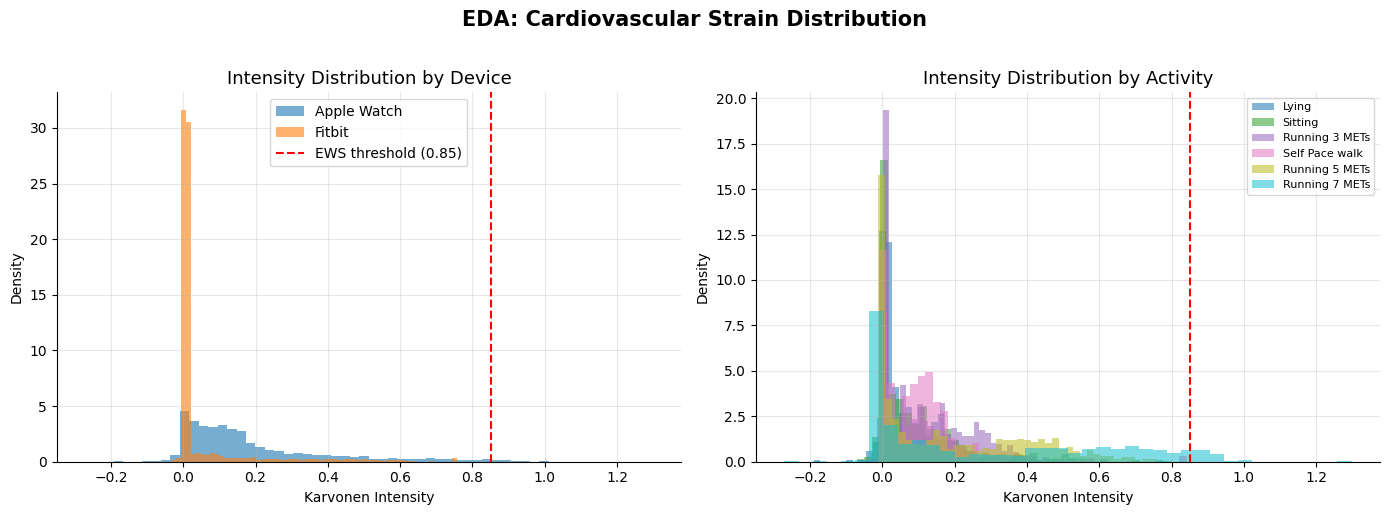

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by device
ax = axes[0]
for dev, grp in df.groupby('device'):
    color = PALETTE.get(dev, 'steelblue')
    ax.hist(grp[TARGET_COL], bins=60, alpha=0.6, label=dev.title(), color=color, density=True)
ax.axvline(0.85, color='red', ls='--', lw=1.5, label='EWS threshold (0.85)')
ax.set_title('Intensity Distribution by Device', fontsize=13)
ax.set_xlabel('Karvonen Intensity')
ax.set_ylabel('Density')
ax.legend()

# Distribution by activity
ax = axes[1]
activity_order = df.groupby('activity')[TARGET_COL].median().sort_values().index
cmap = cm.get_cmap('tab10', len(activity_order))
for i, act in enumerate(activity_order):
    grp = df[df['activity'] == act]
    ax.hist(grp[TARGET_COL], bins=40, alpha=0.55, label=act, color=cmap(i), density=True)
ax.axvline(0.85, color='red', ls='--', lw=1.5)
ax.set_title('Intensity Distribution by Activity', fontsize=13)
ax.set_xlabel('Karvonen Intensity')
ax.set_ylabel('Density')
ax.legend(fontsize=8, loc='upper right')

fig.suptitle('EDA: Cardiovascular Strain Distribution', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, '01_target_distribution.png')
plt.show()

  Saved → outputs/figures/02_correlation_heatmap.png


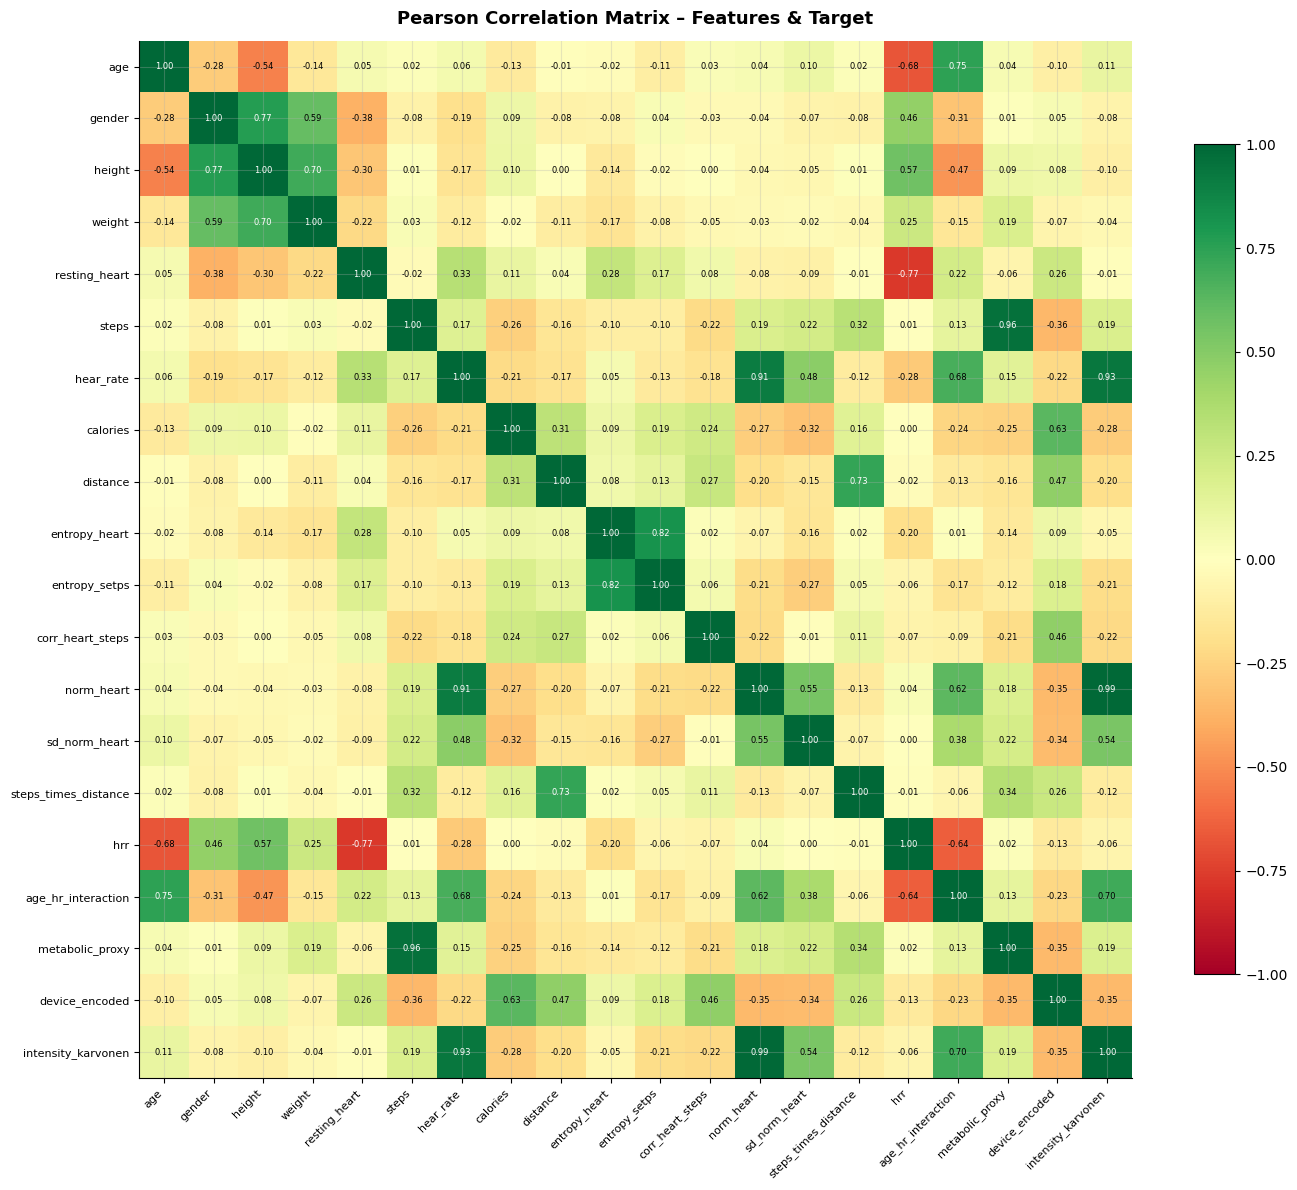

In [11]:
numeric_cols = [c for c in ALL_FEATURES + [TARGET_COL] if c in df.columns]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color='black' if abs(val) < 0.7 else 'white')
ax.set_title('Pearson Correlation Matrix – Features & Target', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
save_fig(fig, '02_correlation_heatmap.png')
plt.show()

  Saved → outputs/figures/03_resting_hr_vs_age.png


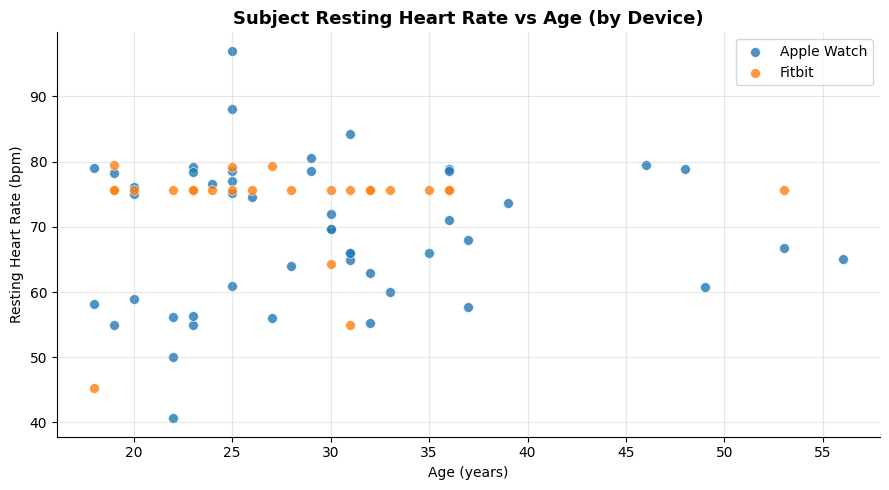

In [12]:
sub_level = df.groupby(['subject_id', 'device']).agg(
    age=('age', 'first'),
    resting_hr=('resting_heart', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for dev, grp in sub_level.groupby('device'):
    color = PALETTE.get(dev, 'steelblue')
    ax.scatter(grp['age'], grp['resting_hr'], label=dev.title(),
               color=color, alpha=0.8, s=50, edgecolors='white', lw=0.5)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Resting Heart Rate (bpm)')
ax.set_title('Subject Resting Heart Rate vs Age (by Device)', fontsize=13, fontweight='bold')
ax.legend()
fig.tight_layout()
save_fig(fig, '03_resting_hr_vs_age.png')
plt.show()

Model Training

Two models are compared:
- **ElasticNet** — linear baseline with L1+L2 regularisation (interpretable, fast)
- **GBM** — gradient boosting ensemble (captures non-linear thresholds, feature importances)

Both are wrapped in a `StandardScaler → model` pipeline and tuned via `GridSearchCV` with `GroupKFold` so every inner fold also respects subject boundaries.

In [13]:
def build_elasticnet_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
    ])


def build_gbm_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ])


def tune_model(pipeline, param_grid, X_train, y_train, groups_train, n_folds=N_CV_FOLDS):
    cv     = GroupKFold(n_splits=n_folds)
    scorer = make_scorer(mean_absolute_error, greater_is_better=False)
    gs = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid,
        cv         = cv,
        scoring    = scorer,
        n_jobs     = -1,
        refit      = True,
    )
    gs.fit(X_train, y_train, groups=groups_train)
    return gs


def get_feature_importances(fitted_gs, feature_names):
    model_step = fitted_gs.best_estimator_.named_steps['model']
    if hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
    elif hasattr(model_step, 'coef_'):
        importances = np.abs(model_step.coef_)
    else:
        return {}
    return dict(sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True))

In [14]:
models_and_grids = {
    'ElasticNet': (build_elasticnet_pipeline(), ELASTICNET_PARAM_GRID),
    'GBM'       : (build_gbm_pipeline(),        GBM_PARAM_GRID),
}

fitted_models = {}

for model_name, (pipeline, param_grid) in models_and_grids.items():
    print(f'\nTuning {model_name}...')
    t0 = time.time()
    gs = tune_model(pipeline, param_grid,
                    X_train.values, y_train.values, groups_train)
    elapsed = time.time() - t0
    print(f'  Best params : {gs.best_params_}')
    print(f'  Best CV MAE : {-gs.best_score_:.4f}')
    print(f'  Time        : {elapsed:.1f} s')
    fitted_models[model_name] = gs


Tuning ElasticNet...
  Best params : {'model__alpha': 0.001, 'model__l1_ratio': 0.5}
  Best CV MAE : 0.0115
  Time        : 4.2 s

Tuning GBM...
  Best params : {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__n_estimators': 400, 'model__subsample': 0.8}
  Best CV MAE : 0.0041
  Time        : 394.4 s


In [15]:
def compute_metrics(y_true, y_pred, label=''):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = np.abs(y_true) >= 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan
    return {'Label': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape}


def per_device_metrics(df_test, y_pred, model_name=''):
    df = df_test.copy()
    df['y_pred'] = y_pred
    rows = []
    for dev in df['device'].unique():
        sub = df[df['device'] == dev]
        m = compute_metrics(sub[TARGET_COL], sub['y_pred'], label=f'{model_name} | {dev}')
        rows.append(m)
    return pd.DataFrame(rows).set_index('Label')


def per_activity_metrics(df_test, y_pred, model_name=''):
    df = df_test.copy()
    df['y_pred'] = y_pred
    rows = []
    for act in df['activity'].unique():
        sub = df[df['activity'] == act]
        m = compute_metrics(sub[TARGET_COL], sub['y_pred'], label=f'{model_name} | {act}')
        m['n_rows'] = len(sub)
        rows.append(m)
    return pd.DataFrame(rows).set_index('Label').sort_values('MAE')


def build_comparison_table(results):
    rows = []
    for name, m in results.items():
        rows.append({
            'Model' : name,
            'MAE'   : round(m['MAE'],    4),
            'RMSE'  : round(m['RMSE'],   4),
            'R²'    : round(m['R2'],     4),
            'MAPE_%': round(m['MAPE_%'], 2) if not np.isnan(m['MAPE_%']) else np.nan,
        })
    return pd.DataFrame(rows).set_index('Model')

In [16]:
all_predictions  = {}
all_metrics      = {}
device_metrics   = {}
activity_metrics = {}
y_true = y_test.values

for model_name, gs in fitted_models.items():
    y_pred = gs.predict(X_test.values)
    all_predictions[model_name]  = y_pred

    m = compute_metrics(y_true, y_pred, label=model_name)
    all_metrics[model_name]      = m

    device_metrics[model_name]   = per_device_metrics(df_test, y_pred, model_name)
    activity_metrics[model_name] = per_activity_metrics(df_test, y_pred, model_name)

    print(f'\n{model_name}')
    print(f'  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}  R²={m["R2"]:.4f}  MAPE={m["MAPE_%"]:.2f}%')

comparison_df = build_comparison_table(all_metrics)
print('\n--- Model Comparison ---')
display(comparison_df)
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'))


ElasticNet
  MAE=0.0111  RMSE=0.0176  R²=0.9918  MAPE=19.47%

GBM
  MAE=0.0041  RMSE=0.0089  R²=0.9979  MAPE=3.89%

--- Model Comparison ---


,MAE,RMSE,R²,MAPE_%
Model,,,,
ElasticNet,0.0111,0.0176,0.9918,19.47
GBM,0.0041,0.0089,0.9979,3.89


In [17]:
print('Per-device metrics:')
for name, df_dev in device_metrics.items():
    print(f'\n{name}')
    display(df_dev)

Per-device metrics:

ElasticNet


,MAE,RMSE,R2,MAPE_%
Label,,,,
ElasticNet | apple watch,0.013369,0.020267,0.990113,12.548042
ElasticNet | fitbit,0.006656,0.010516,-3.856540,58.161561



GBM


,MAE,RMSE,R2,MAPE_%
Label,,,,
GBM | apple watch,0.005828,0.010855,0.997164,3.265125
GBM | fitbit,0.000624,0.001228,0.933729,7.411132


In [18]:
print('Per-activity metrics:')
for name, df_act in activity_metrics.items():
    print(f'\n{name}')
    display(df_act)

Per-activity metrics:

ElasticNet


,MAE,RMSE,R2,MAPE_%,n_rows
Label,,,,,
ElasticNet | Running 3 METs,0.006571,0.009395,0.993808,18.884719,173
ElasticNet | Self Pace walk,0.007545,0.010380,0.973433,20.479520,163
ElasticNet | Sitting,0.009190,0.013377,0.990141,23.305987,177
ElasticNet | Lying,0.009398,0.013454,0.985177,29.643506,242
ElasticNet | Running 5 METs,0.013013,0.017905,0.992975,9.410881,185
ElasticNet | Running 7 METs,0.020804,0.031382,0.989807,8.672514,184



GBM


,MAE,RMSE,R2,MAPE_%,n_rows
Label,,,,,
GBM | Self Pace walk,0.002269,0.003685,0.996652,3.428161,163
GBM | Lying,0.002571,0.006153,0.996900,4.826752,242
GBM | Sitting,0.002912,0.006397,0.997745,4.516800,177
GBM | Running 3 METs,0.003973,0.007398,0.996160,3.974556,173
GBM | Running 5 METs,0.006276,0.012988,0.996304,2.861557,185
GBM | Running 7 METs,0.006729,0.012641,0.998346,3.364420,184


Clinical Analysis – Risk Zones & Early Warning System

In [19]:
def assign_risk_zone(intensity):
    for zone_name, (lo, hi) in RISK_ZONES.items():
        if lo <= intensity < hi:
            return zone_name
    return list(RISK_ZONES.keys())[-1]


def risk_zone_accuracy(y_true, y_pred):
    zones_true = [assign_risk_zone(v) for v in y_true]
    zones_pred = [assign_risk_zone(v) for v in y_pred]
    df = pd.DataFrame({'true_zone': zones_true, 'pred_zone': zones_pred})
    zone_order = list(RISK_ZONES.keys())
    rows = []
    for zone in zone_order:
        tp = ((df.true_zone == zone) & (df.pred_zone == zone)).sum()
        fp = ((df.true_zone != zone) & (df.pred_zone == zone)).sum()
        fn = ((df.true_zone == zone) & (df.pred_zone != zone)).sum()
        n  = (df.true_zone == zone).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall    = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else np.nan)
        rows.append({'Zone': zone, 'N_true': n,
                     'Precision': round(precision, 4) if not np.isnan(precision) else np.nan,
                     'Recall'   : round(recall,    4) if not np.isnan(recall)    else np.nan,
                     'F1'       : round(f1,        4) if not np.isnan(f1)        else np.nan})
    return pd.DataFrame(rows).set_index('Zone')


def early_warning_system(df_test, y_pred):
    df = df_test.copy()
    df['y_pred'] = y_pred
    ews_mask = (
        df['activity'].isin(LOW_ACTIVITY_LABELS) &
        (df['y_pred'] >= EWS_INTENSITY_THRESHOLD)
    )
    flagged = df[ews_mask][[
        'subject_id', 'device', 'activity',
        TARGET_COL, 'y_pred', 'hear_rate', 'resting_heart', 'age',
    ]].copy().rename(columns={TARGET_COL: 'actual_intensity'})

    also_true = (
        df['activity'].isin(LOW_ACTIVITY_LABELS) &
        (df[TARGET_COL] >= EWS_INTENSITY_THRESHOLD)
    ).sum()

    print(f'EWS threshold: intensity >= {EWS_INTENSITY_THRESHOLD} during {LOW_ACTIVITY_LABELS}')
    print(f'  Ground-truth triggers : {also_true}')
    print(f'  Model-predicted flags : {len(flagged)}')
    return flagged


def per_subject_metrics(df_test, y_pred):
    df = df_test.copy()
    df['y_pred'] = y_pred
    rows = []
    for subj in sorted(df['subject_id'].unique()):
        sub = df[df['subject_id'] == subj]
        rows.append({
            'subject_id': subj,
            'n_rows'    : len(sub),
            'MAE'       : round(mean_absolute_error(sub[TARGET_COL], sub['y_pred']), 4),
            'R2'        : round(r2_score(sub[TARGET_COL], sub['y_pred']), 4),
            'device'    : ', '.join(sub['device'].unique()),
        })
    return pd.DataFrame(rows).set_index('subject_id')

In [20]:
best_model_name = max(all_metrics, key=lambda k: all_metrics[k]['R2'])
best_preds      = all_predictions[best_model_name]
print(f'Best model (highest R²): {best_model_name}')

# Risk zone precision / recall / F1
zone_df = risk_zone_accuracy(y_true, best_preds)
print('\nRisk Zone Classification Metrics:')
display(zone_df)
zone_df.to_csv(os.path.join(OUTPUT_DIR, 'risk_zone_metrics.csv'))

# Early Warning System
ews_df = early_warning_system(df_test, best_preds)
if len(ews_df) > 0:
    print(f'\nEWS – {len(ews_df)} flagged observations:')
    display(ews_df.head(10))
ews_df.to_csv(os.path.join(OUTPUT_DIR, 'ews_flags.csv'))

# Per-subject generalisation
subj_df = per_subject_metrics(df_test, best_preds)
print(f'\nPer-Subject Generalisation ({best_model_name}):')
display(subj_df)
subj_df.to_csv(os.path.join(OUTPUT_DIR, 'per_subject_metrics.csv'))

Best model (highest R²): GBM

Risk Zone Classification Metrics:


,N_true,Precision,Recall,F1
Zone,,,,
Zone 1 – Recovery,814,0.9939,0.9951,0.9945
Zone 2 – Light Aerobic,162,0.9290,0.9691,0.9486
Zone 3 – Moderate Aerobic,99,0.9479,0.9192,0.9333
Zone 4 – Anaerobic Threshold,38,1.0000,0.8684,0.9296
Zone 5 – Maximum Effort,11,1.0000,1.0000,1.0000


EWS threshold: intensity >= 0.85 during ['Lying', 'Sitting', 'Self Pace walk']
  Ground-truth triggers : 0
  Model-predicted flags : 0

Per-Subject Generalisation (GBM):


,n_rows,MAE,R2,device
subject_id,,,,
13,148,0.0010,0.9938,"apple watch, fitbit"
17,156,0.0025,0.9992,"apple watch, fitbit"
19,74,0.0034,0.9994,apple watch
25,74,0.0048,0.9990,apple watch
26,73,0.0039,0.9982,apple watch
27,142,0.0004,0.9995,"apple watch, fitbit"
31,154,0.0016,0.9990,"apple watch, fitbit"
44,72,0.0179,0.9918,apple watch
45,79,0.0152,0.9931,apple watch


Visualisations

  Saved → outputs/figures/04_actual_vs_predicted.png


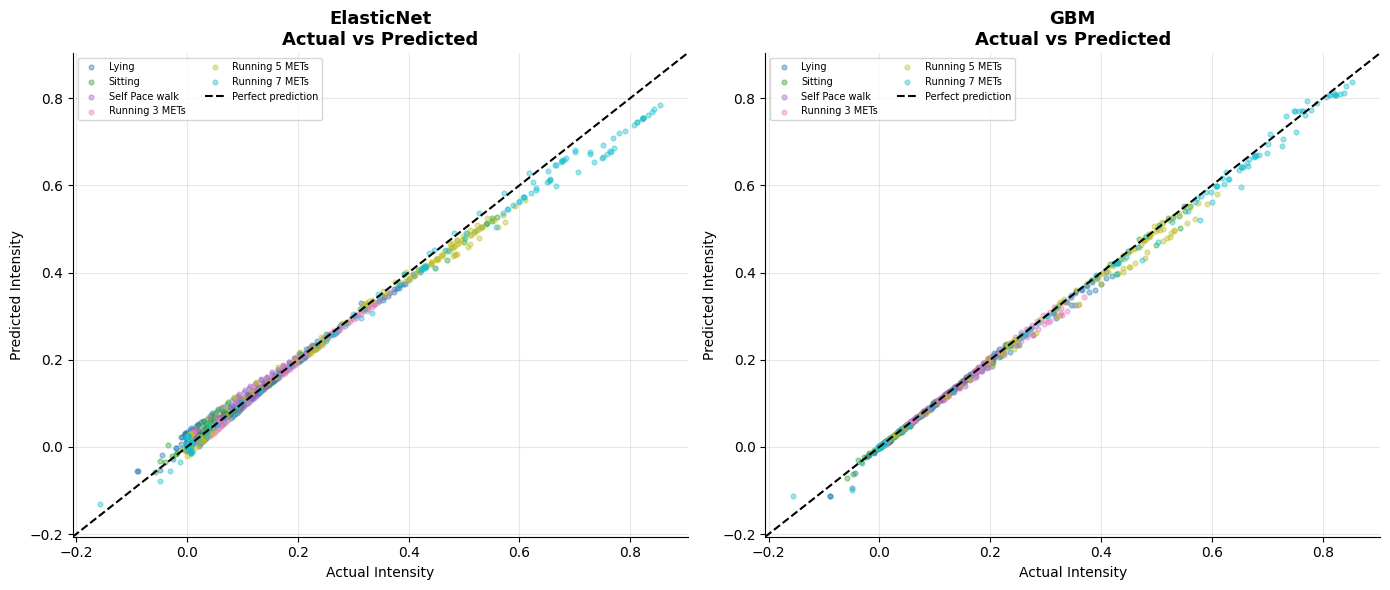

In [21]:
# Actual vs Predicted scatter — one panel per model, coloured by activity
n_models = len(all_predictions)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)

activities = df_test['activity'].unique()
cmap       = cm.get_cmap('tab10', len(activities))
act_colors = {a: cmap(i) for i, a in enumerate(activities)}

y_true_s = pd.Series(y_true)
for idx, (name, y_pred) in enumerate(all_predictions.items()):
    ax = axes[0][idx]
    for act in activities:
        mask = df_test.reset_index(drop=True)['activity'] == act
        ax.scatter(y_true_s[mask], np.array(y_pred)[mask],
                   color=act_colors[act], alpha=0.4, s=12, label=act)
    lo = min(y_true_s.min(), min(y_pred)) - 0.05
    hi = max(y_true_s.max(), max(y_pred)) + 0.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Intensity'); ax.set_ylabel('Predicted Intensity')
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7, ncol=2, loc='upper left')

fig.tight_layout()
save_fig(fig, '04_actual_vs_predicted.png')
plt.show()

  Saved → outputs/figures/05_residuals.png


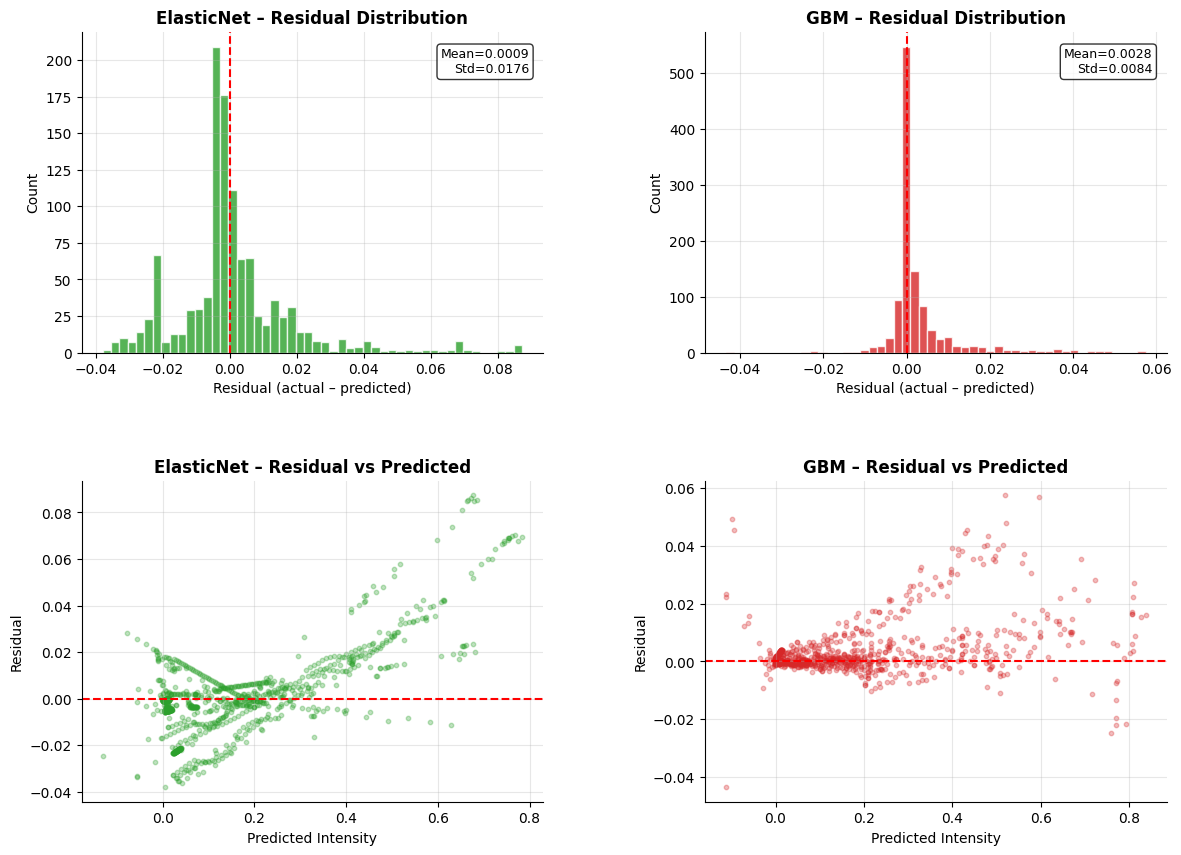

In [22]:
# Residual distributions and residual-vs-predicted plots
fig = plt.figure(figsize=(14, 10))
gs_layout = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

model_items = list(all_predictions.items())
colors      = [PALETTE['elasticnet'], PALETTE['gbm']]

for col, (name, y_pred) in enumerate(model_items):
    residuals = y_true - np.array(y_pred)
    color     = colors[col]

    # Histogram of residuals
    ax_hist = fig.add_subplot(gs_layout[0, col])
    ax_hist.hist(residuals, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax_hist.axvline(0, color='red', ls='--', lw=1.5)
    ax_hist.set_title(f'{name} – Residual Distribution', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel('Residual (actual – predicted)')
    ax_hist.set_ylabel('Count')
    stats_txt = f'Mean={residuals.mean():.4f}\nStd={residuals.std():.4f}'
    ax_hist.text(0.97, 0.95, stats_txt, transform=ax_hist.transAxes,
                 ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Residual vs Predicted scatter
    ax_sc = fig.add_subplot(gs_layout[1, col])
    ax_sc.scatter(y_pred, residuals, color=color, alpha=0.3, s=10)
    ax_sc.axhline(0, color='red', ls='--', lw=1.5)
    ax_sc.set_title(f'{name} – Residual vs Predicted', fontsize=12, fontweight='bold')
    ax_sc.set_xlabel('Predicted Intensity')
    ax_sc.set_ylabel('Residual')

save_fig(fig, '05_residuals.png')
plt.show()

  Saved → outputs/figures/06_feature_importance_elasticnet.png


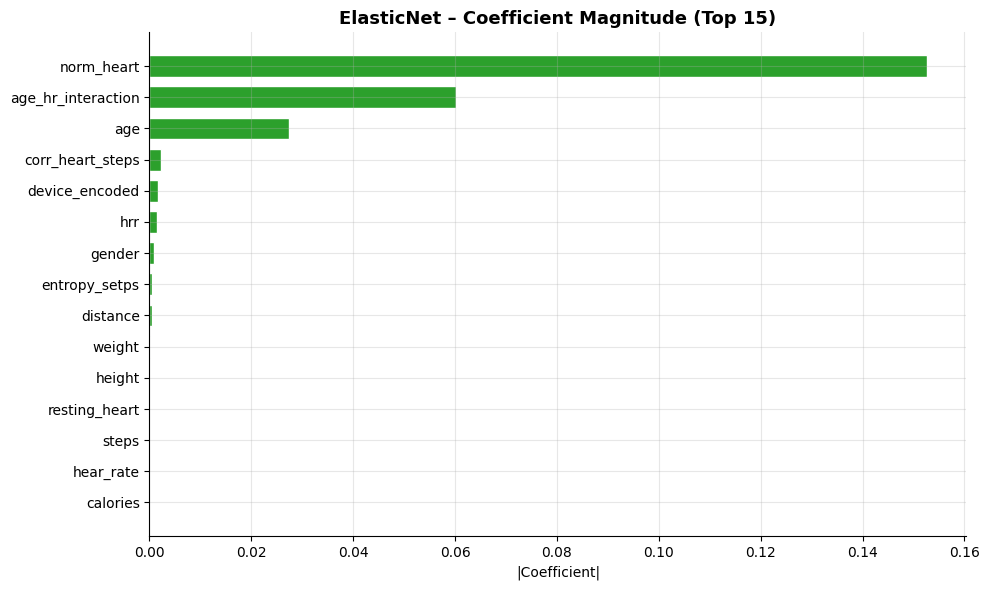

  Saved → outputs/figures/06_feature_importance_gbm.png


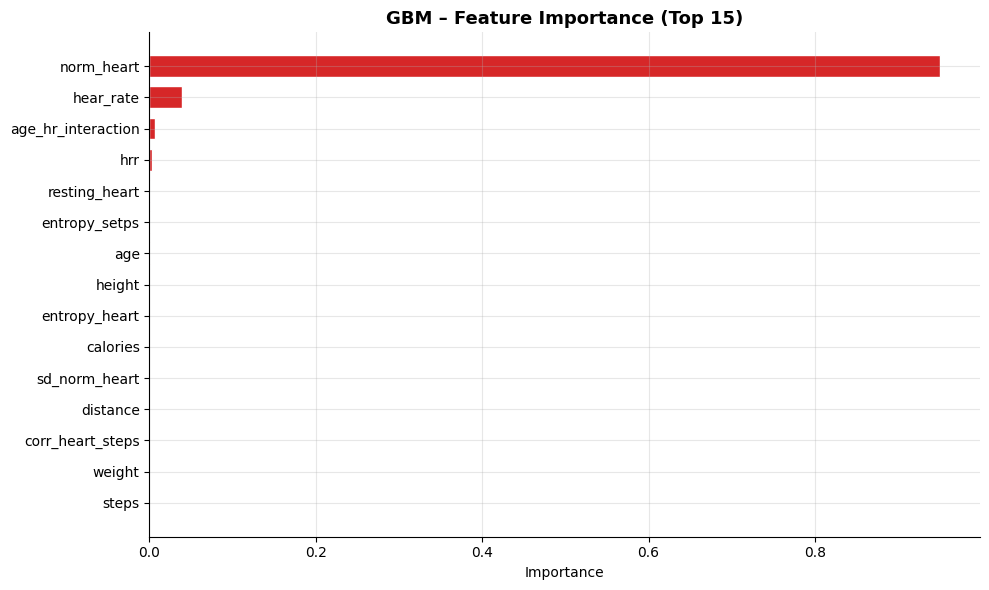

In [23]:
# Feature importance / coefficient magnitude — top 15 features per model
TOP_N = 15

for model_name, gs in fitted_models.items():
    imps = get_feature_importances(gs, feature_names)
    if not imps:
        continue
    top = dict(list(imps.items())[:TOP_N])
    feats  = list(top.keys())[::-1]
    values = list(top.values())[::-1]
    color  = PALETTE.get('elasticnet' if 'lasticNet' in model_name else 'gbm', 'steelblue')

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feats, values, color=color, edgecolor='white', height=0.7)
    title_suffix = 'Feature Importance' if 'lasticNet' not in model_name else 'Coefficient Magnitude'
    ax.set_title(f'{model_name} – {title_suffix} (Top {TOP_N})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance' if 'lasticNet' not in model_name else '|Coefficient|')
    fig.tight_layout()
    fname = f'06_feature_importance_{model_name.lower().replace(" ", "_")}.png'
    save_fig(fig, fname)
    plt.show()

  Saved → outputs/figures/07_per_activity_mae.png


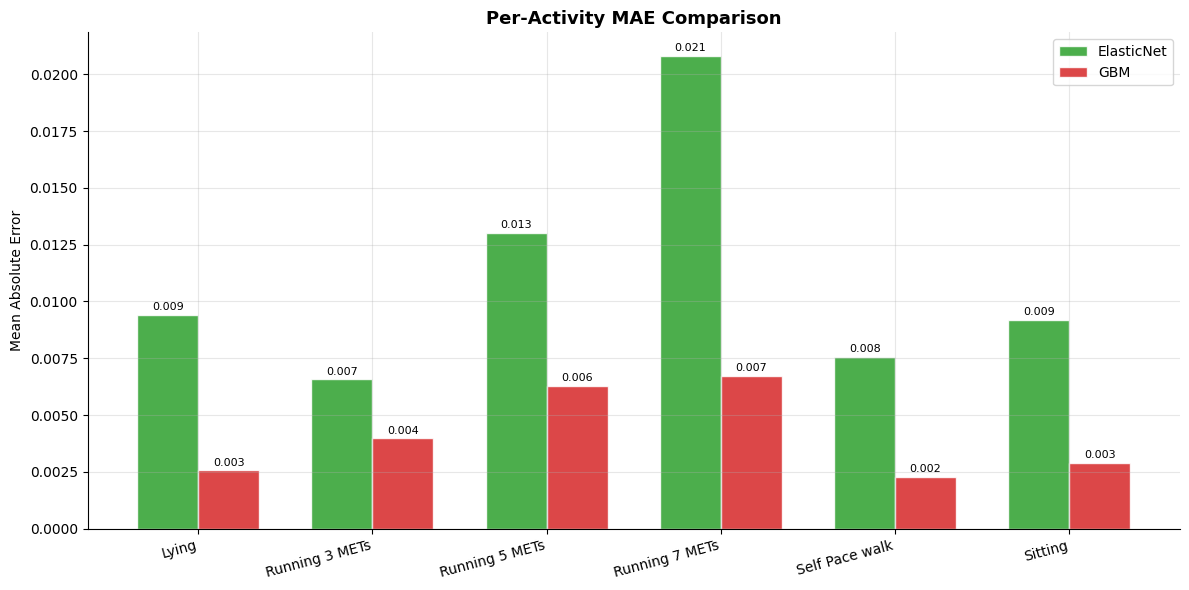

In [24]:
# Per-activity MAE grouped bar chart
all_acts = sorted(set(
    idx.split(' | ')[-1]
    for df_act in activity_metrics.values()
    for idx in df_act.index
))

x = np.arange(len(all_acts))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, df_act) in enumerate(activity_metrics.items()):
    lookup = {idx.split(' | ')[-1]: row['MAE'] for idx, row in df_act.iterrows()}
    maes   = [lookup.get(a, np.nan) for a in all_acts]
    color  = PALETTE.get('elasticnet' if 'lasticNet' in name else 'gbm', 'steelblue')
    offset = (i - (len(activity_metrics) - 1) / 2) * w
    rects  = ax.bar(x + offset, maes, w, label=name, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(rects, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(all_acts, rotation=15, ha='right')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Per-Activity MAE Comparison', fontsize=13, fontweight='bold')
ax.legend()
fig.tight_layout()
save_fig(fig, '07_per_activity_mae.png')
plt.show()

  Saved → outputs/figures/08_per_device_metrics.png


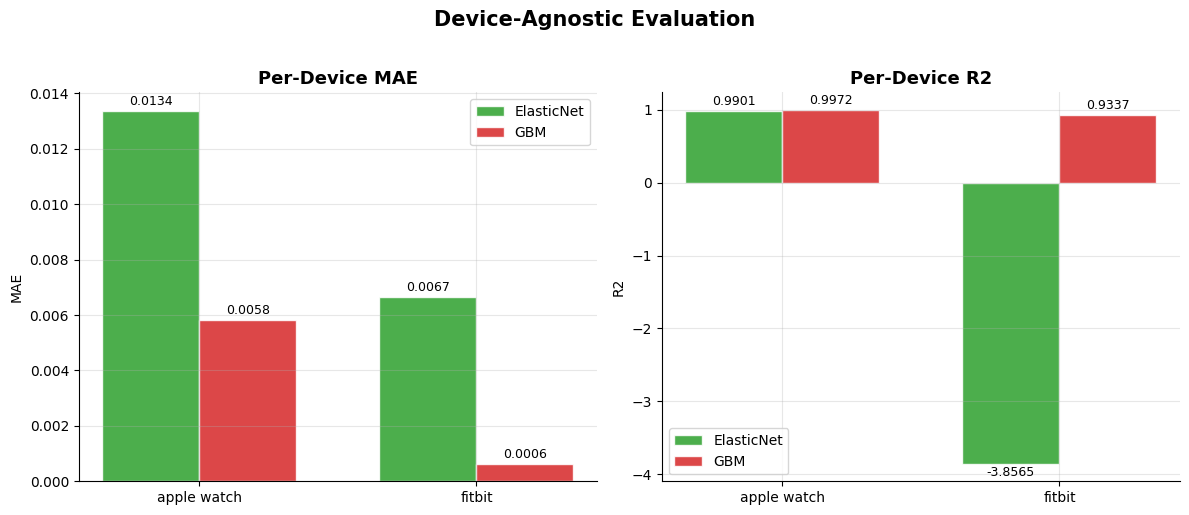

In [25]:
# Per-device MAE and R² grouped bar charts
devices_found = sorted(set(
    idx.split(' | ')[-1]
    for df_dev in device_metrics.values()
    for idx in df_dev.index
))

x = np.arange(len(devices_found))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for m_idx, metric in enumerate(['MAE', 'R2']):
    ax = axes[m_idx]
    for i, (name, df_dev) in enumerate(device_metrics.items()):
        lookup = {idx.split(' | ')[-1]: row[metric] for idx, row in df_dev.iterrows()}
        vals   = [lookup.get(d, np.nan) for d in devices_found]
        color  = PALETTE.get('elasticnet' if 'lasticNet' in name else 'gbm', 'steelblue')
        offset = (i - (len(device_metrics) - 1) / 2) * w
        rects  = ax.bar(x + offset, vals, w, label=name, color=color, alpha=0.85, edgecolor='white')
        ax.bar_label(rects, fmt='%.4f', fontsize=9, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(devices_found)
    ax.set_ylabel(metric)
    ax.set_title(f'Per-Device {metric}', fontsize=13, fontweight='bold')
    ax.legend()

fig.suptitle('Device-Agnostic Evaluation', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, '08_per_device_metrics.png')
plt.show()

  Saved → outputs/figures/09_risk_zone_distribution.png


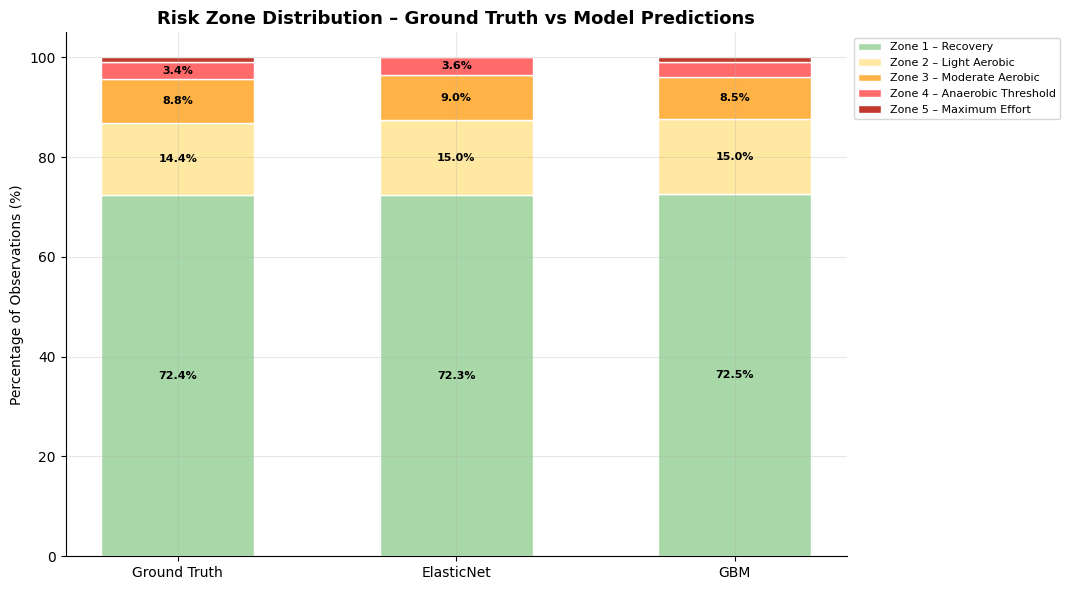

In [26]:
# Risk zone distribution — ground truth vs model predictions
zone_order  = list(RISK_ZONES.keys())
zone_colors = ['#a8d8a8', '#ffe8a1', '#ffb347', '#ff6b6b', '#c0392b']

labels      = ['Ground Truth'] + list(all_predictions.keys())
series_list = [y_true] + [np.array(v) for v in all_predictions.values()]

matrix = np.zeros((len(zone_order), len(labels)))
for s_idx, series in enumerate(series_list):
    zones = [assign_risk_zone(v) for v in series]
    for z_idx, z in enumerate(zone_order):
        matrix[z_idx, s_idx] = zones.count(z) / len(zones) * 100

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(labels))
bottoms = np.zeros(len(labels))

for z_idx, (zone, color) in enumerate(zip(zone_order, zone_colors)):
    vals = matrix[z_idx]
    ax.bar(x, vals, bottom=bottoms, color=color, edgecolor='white', label=zone, width=0.55)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 3:
            ax.text(xi, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='black')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage of Observations (%)')
ax.set_ylim(0, 105)
ax.set_title('Risk Zone Distribution – Ground Truth vs Model Predictions',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.28, 1))
fig.tight_layout()
save_fig(fig, '09_risk_zone_distribution.png')
plt.show()

  Saved → outputs/figures/10_per_subject_r2.png


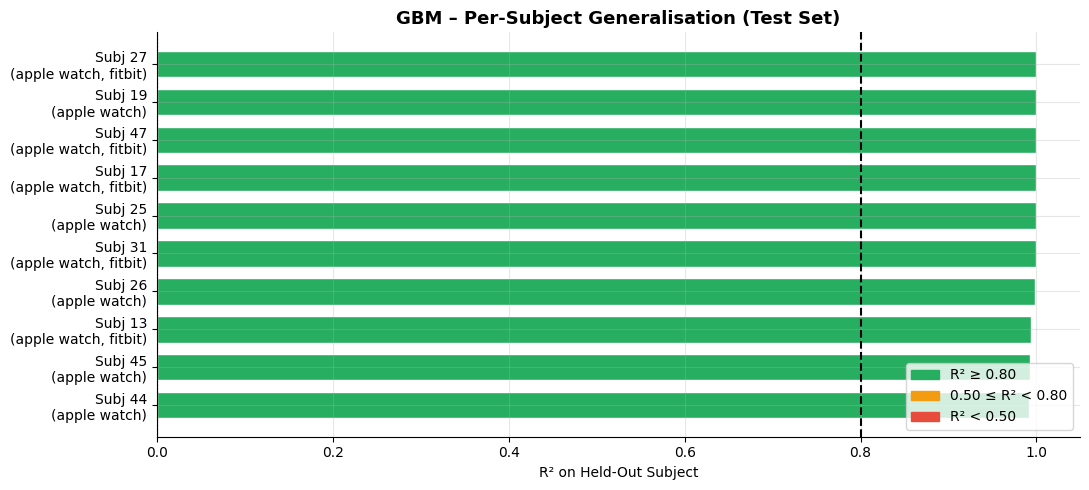

In [27]:
# Per-subject R² on the 10 held-out individuals
df_subj = subj_df.sort_values('R2', ascending=True)
colors  = ['#e74c3c' if r2 < 0.5 else '#f39c12' if r2 < 0.80 else '#27ae60'
           for r2 in df_subj['R2']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    [f'Subj {sid}\n({r})' for sid, r in zip(df_subj.index, df_subj['device'])],
    df_subj['R2'], color=colors, edgecolor='white', height=0.7,
)
ax.axvline(0.80, color='black', ls='--', lw=1.5)
ax.axvline(0,    color='gray',  ls=':',  lw=1.0)
ax.set_xlabel('R² on Held-Out Subject')
ax.set_title(f'{best_model_name} – Per-Subject Generalisation (Test Set)',
             fontsize=13, fontweight='bold')
patches = [
    mpatches.Patch(color='#27ae60', label='R² ≥ 0.80'),
    mpatches.Patch(color='#f39c12', label='0.50 ≤ R² < 0.80'),
    mpatches.Patch(color='#e74c3c', label='R² < 0.50'),
]
ax.legend(handles=patches, loc='lower right')
fig.tight_layout()
save_fig(fig, '10_per_subject_r2.png')
plt.show()

  Saved → outputs/figures/11_model_comparison.png


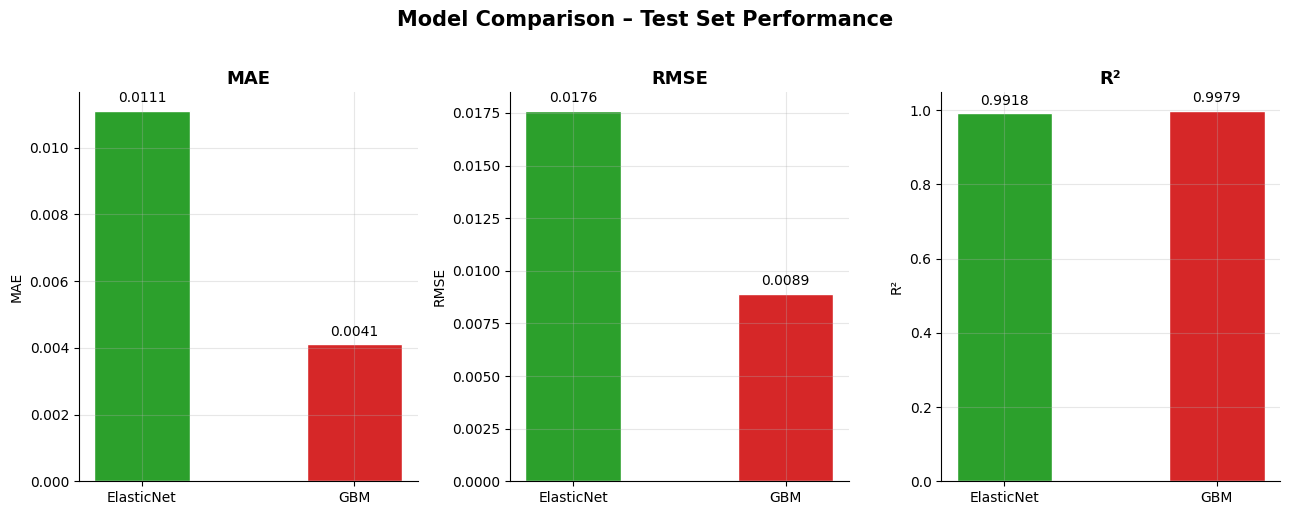

In [28]:
# Side-by-side bar chart: MAE, RMSE, R² across all models
metrics_to_plot = ['MAE', 'RMSE', 'R²']
model_colors = {'ElasticNet': PALETTE['elasticnet'], 'GBM': PALETTE['gbm']}

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, metric in zip(axes, metrics_to_plot):
    vals   = comparison_df[metric]
    colors = [model_colors.get(m, 'steelblue') for m in comparison_df.index]
    bars   = ax.bar(comparison_df.index, vals, color=colors, edgecolor='white', width=0.45)
    ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=4)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)

fig.suptitle('Model Comparison – Test Set Performance',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, '11_model_comparison.png')
plt.show()

In [29]:
for model_name, gs in fitted_models.items():
    path = os.path.join(OUTPUT_DIR, f'{model_name.lower()}_model.pkl')
    joblib.dump(gs, path)
    print(f'Saved {model_name} → {path}')

Saved ElasticNet → outputs/elasticnet_model.pkl
Saved GBM → outputs/gbm_model.pkl


In [30]:
def predict_from_dict(model, obs):
    """
    Predict cardiovascular strain for a single wearable observation.

    Parameters
    ----------
    model : fitted GridSearchCV or Pipeline
    obs   : dict with raw sensor values matching the training column names

    Returns
    -------
    dict with predicted_intensity, risk_zone, ews_flag, ews_message
    """
    df_row = pd.DataFrame([obs])
    df_row['device_encoded'] = (df_row['device'].str.lower().str.strip() == 'fitbit').astype(int)
    df_row = engineer_features(df_row)
    available = [f for f in ALL_FEATURES if f in df_row.columns]
    X = df_row[available].values

    intensity = float(model.predict(X)[0])
    risk_zone = assign_risk_zone(intensity)

    activity = obs.get('activity', 'unknown')
    ews_flag = activity in LOW_ACTIVITY_LABELS and intensity >= EWS_INTENSITY_THRESHOLD
    ews_message = (
        f'⚠ EWS ALERT: Predicted intensity {intensity:.3f} >= '
        f'{EWS_INTENSITY_THRESHOLD} during "{activity}". '
        'Potential cardiovascular over-exertion detected.'
        if ews_flag else '✓ No anomaly detected.'
    )

    return {
        'predicted_intensity': round(intensity, 4),
        'risk_zone'          : risk_zone,
        'ews_flag'           : ews_flag,
        'ews_message'        : ews_message,
    }

In [31]:
best_gs = fitted_models[best_model_name]

demo_cases = [
    {
        'description': 'Healthy adult running at high intensity',
        'obs': {
            'age': 28, 'gender': 0, 'height': 165.0, 'weight': 62.0,
            'steps': 120.0, 'hear_rate': 155.0, 'calories': 12.0,
            'distance': 0.09, 'entropy_heart': 6.1, 'entropy_setps': 6.0,
            'resting_heart': 60.0, 'corr_heart_steps': 0.95,
            'norm_heart': 95.0, 'sd_norm_heart': 2.1,
            'steps_times_distance': 10.8, 'device': 'apple watch',
            'activity': 'Running 7 METs',
        },
    },
    {
        'description': 'Potential CVD risk – high HR while lying',
        'obs': {
            'age': 55, 'gender': 1, 'height': 178.0, 'weight': 95.0,
            'steps': 5.0, 'hear_rate': 135.0, 'calories': 1.5,
            'distance': 0.003, 'entropy_heart': 5.2, 'entropy_setps': 4.0,
            'resting_heart': 72.0, 'corr_heart_steps': 0.10,
            'norm_heart': 63.0, 'sd_norm_heart': 3.5,
            'steps_times_distance': 0.015, 'device': 'fitbit',
            'activity': 'Lying',
        },
    },
]

print('Demo inference\n' + '='*50)
for case in demo_cases:
    print(f'\nCase: {case["description"]}')
    result = predict_from_dict(best_gs, case['obs'])
    for k, v in result.items():
        print(f'  {k:<24}: {v}')

Demo inference

Case: Healthy adult running at high intensity
  predicted_intensity     : 0.6989
  risk_zone               : Zone 4 – Anaerobic Threshold
  ews_flag                : False
  ews_message             : ✓ No anomaly detected.

Case: Potential CVD risk – high HR while lying
  predicted_intensity     : 0.6392
  risk_zone               : Zone 4 – Anaerobic Threshold
  ews_flag                : False
  ews_message             : ✓ No anomaly detected.
